# PyTorch MLP

This notebook trains a **Multi-Layer Perceptron (MLP)** neural network model on the tabular audio features extracted from the dataset.

### Overview
- **Input**: Tabular feature data (`train.csv`, `valid.csv`, `test.csv`) which contains extracted audio features.
- **Model**: A deep neural network built using PyTorch with fully connected layers, dropout, and batch normalization.
- **Training**: Trained using Adam optimizer and CrossEntropy loss.

### Usage on Kaggle
If running on Kaggle, ensure the dataset is mounted and update the `DATA_DIR` path to point to `../input/song-genre-classification/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BASE_DIR = Path.cwd().parents[1]
DATA_DIR = BASE_DIR

TRAIN_CSV = DATA_DIR / "train.csv"
VAL_CSV = DATA_DIR / "valid.csv"
TEST_CSV = DATA_DIR / "test.csv"

MODELS_DIR = BASE_DIR / "models" / "features"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "mlp.pt"

Using device: cuda


In [2]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Valid shape:", val_df.shape)
print("Test shape:", test_df.shape)

TARGET_COL = "Genre"
IGNORE_COLS = [TARGET_COL, "Filename"]

feature_cols = [c for c in train_df.columns if c not in IGNORE_COLS]

X_train_np = train_df[feature_cols].values.astype(np.float32)
y_train_str = train_df[TARGET_COL].values

X_val_np = val_df[feature_cols].values.astype(np.float32)
y_val_str = val_df[TARGET_COL].values

X_test_np = test_df[feature_cols].values.astype(np.float32)
y_test_str = test_df[TARGET_COL].values

Train shape: (12208, 33)
Valid shape: (2442, 33)
Test shape: (1610, 33)


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_val_scaled = scaler.transform(X_val_np)
X_test_scaled = scaler.transform(X_test_np)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_str)
y_val = label_encoder.transform(y_val_str)
y_test = label_encoder.transform(y_test_str)

num_classes = len(label_encoder.classes_)
input_dim = X_train_scaled.shape[1]

print("Classes:", list(label_encoder.classes_))
print("num_classes =", num_classes)
print("input_dim =", input_dim)

Classes: ['country', 'edm', 'hiphop', 'jazz', 'kpop', 'lofi', 'pop', 'r&b', 'rock']
num_classes = 9
input_dim = 31


In [4]:
batch_size = 64

train_dataset = TensorDataset(
    torch.from_numpy(X_train_scaled), torch.from_numpy(y_train.astype(np.int64))
)
val_dataset = TensorDataset(
    torch.from_numpy(X_val_scaled), torch.from_numpy(y_val.astype(np.int64))
)
test_dataset = TensorDataset(
    torch.from_numpy(X_test_scaled), torch.from_numpy(y_test.astype(np.int64))
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

len(train_loader), len(val_loader), len(test_loader)

(191, 39, 26)

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model = MLP(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=31, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=9, bias=True)
  )
)


In [6]:
def evaluate(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total if total > 0 else 0.0

num_epochs = 40
best_val_acc = 0.0
train_acc_history = []
val_acc_history = []

for epoch in range(1, num_epochs + 1):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_acc = evaluate(model, train_loader)
    val_acc = evaluate(model, val_loader)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)

    print(f"Epoch {epoch:03d}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}, best_val={best_val_acc:.4f}")

print("Training finished. Best val accuracy:", best_val_acc)

Epoch 001: train_acc=0.4940, val_acc=0.4533, best_val=0.4533
Epoch 002: train_acc=0.5346, val_acc=0.4803, best_val=0.4803
Epoch 003: train_acc=0.5429, val_acc=0.4730, best_val=0.4803
Epoch 004: train_acc=0.5595, val_acc=0.4869, best_val=0.4869
Epoch 005: train_acc=0.5732, val_acc=0.4951, best_val=0.4951
Epoch 006: train_acc=0.5811, val_acc=0.5029, best_val=0.5029
Epoch 007: train_acc=0.5879, val_acc=0.5152, best_val=0.5152
Epoch 008: train_acc=0.5940, val_acc=0.5066, best_val=0.5152
Epoch 009: train_acc=0.6058, val_acc=0.5143, best_val=0.5152
Epoch 010: train_acc=0.6139, val_acc=0.5053, best_val=0.5152
Epoch 011: train_acc=0.6224, val_acc=0.5278, best_val=0.5278
Epoch 012: train_acc=0.6301, val_acc=0.5176, best_val=0.5278
Epoch 013: train_acc=0.6338, val_acc=0.5225, best_val=0.5278
Epoch 014: train_acc=0.6394, val_acc=0.5278, best_val=0.5278
Epoch 015: train_acc=0.6411, val_acc=0.5213, best_val=0.5278
Epoch 016: train_acc=0.6507, val_acc=0.5315, best_val=0.5315
Epoch 017: train_acc=0.6

In [7]:
best_model = MLP(input_dim=input_dim, num_classes=num_classes).to(device)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

train_acc_final = evaluate(best_model, train_loader)
val_acc_final = evaluate(best_model, val_loader)
test_acc_final = evaluate(best_model, test_loader)

print(f"Final Train accuracy: {train_acc_final:.4f}")
print(f"Final Val accuracy:   {val_acc_final:.4f}")
print(f"Final Test accuracy:  {test_acc_final:.4f}")

def get_all_preds_labels(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(yb.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


y_test_preds, y_test_true = get_all_preds_labels(best_model, test_loader)

print("\nTest classification report:")
print(classification_report(y_test_true, y_test_preds, target_names=label_encoder.classes_))

print("Test confusion matrix (numeric labels):")
print(confusion_matrix(y_test_true, y_test_preds))

C:\Users\LOQ\AppData\Local\Temp\ipykernel_10876\3217433238.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(MODEL_PATH, map_location

Final Train accuracy: 0.7351
Final Val accuracy:   0.5393
Final Test accuracy:  0.5410

Test classification report:
              precision    recall  f1-score   support

     country       0.50      0.55      0.52       191
         edm       0.49      0.42      0.45       220
      hiphop       0.65      0.56      0.60       172
        jazz       0.68      0.60      0.64        96
        kpop       0.52      0.53      0.53       194
        lofi       0.82      0.86      0.84       173
         pop       0.35      0.31      0.33       197
         r&b       0.46      0.59      0.52       173
        rock       0.50      0.54      0.52       194

    accuracy                           0.54      1610
   macro avg       0.55      0.55      0.55      1610
weighted avg       0.54      0.54      0.54      1610

Test confusion matrix (numeric labels):
[[105  16   1   7   6   5   7  17  27]
 [ 20  92  10   3  27   3  37   5  23]
 [  3   9  97   0   9   9   9  25  11]
 [  8  10   1  58   2 

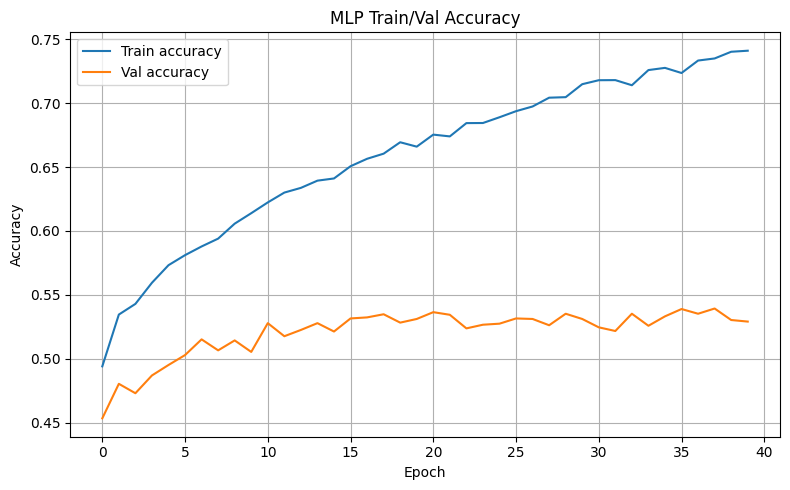

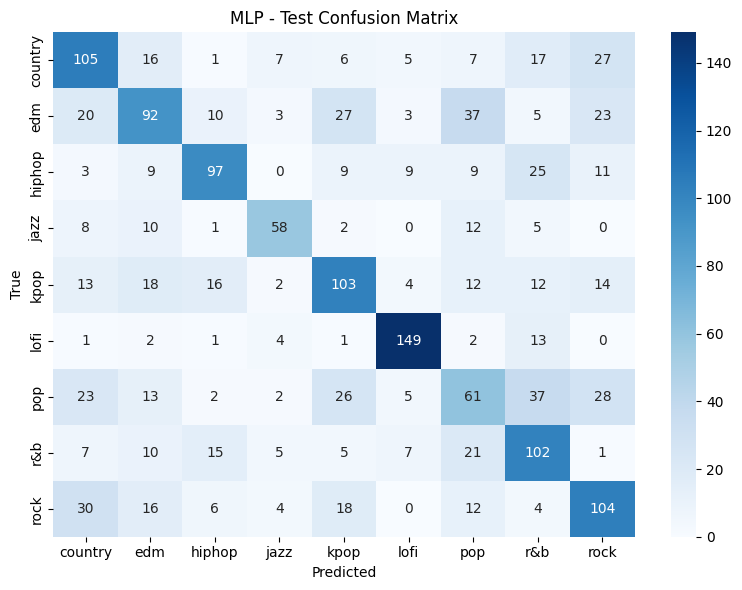

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label="Train accuracy")
plt.plot(val_acc_history, label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Train/Val Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrix heatmap on test set
cm = confusion_matrix(y_test_true, y_test_preds)
labels = list(label_encoder.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MLP - Test Confusion Matrix")
plt.tight_layout()
plt.show()